In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_excel("Retail-Supply-Chain-Sales-Dataset.xlsx", sheet_name="Retails Order Full Dataset")
calender = pd.read_excel("Retail-Supply-Chain-Sales-Dataset.xlsx", sheet_name="Calendar Table")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Retail Sales People,Product ID,Category,Sub-Category,Product Name,Returned,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,Not,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Cassandra Brandow,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",Not,731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06,2016-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Anna Andreadi,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,Not,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,Not,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Cassandra Brandow,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,Not,22.3680,2,0.20,2.5164


In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
calender['Date'] = pd.to_datetime(calender['Date'])

order_date_df = calender[['Date', 'Year', 'Quarter', 'Month Name', 'Week of Year', 'Day Name']].rename(columns={
    'Year': "Order Year",
    'Quarter': 'Order Quarter',
    "Month Name": "Order Month",
    "Week of Year": "Order Week",
    "Day Name": "Order Day"
    })

ship_date_df = calender[['Date', 'Year', 'Quarter', 'Month Name', 'Week of Year', 'Day Name']].rename(columns={
    'Year': "Ship Year",
    'Quarter': 'Ship Quarter',
    "Month Name": "Ship Month",
    "Week of Year": "Ship Week",
    "Day Name": "Ship Day"
    })

final_df = pd.merge(df, order_date_df, left_on='Order Date', right_on='Date', how='left')
final_df = final_df.drop(columns=['Date'])
final_df = pd.merge(final_df, ship_date_df, left_on='Ship Date', right_on='Date', how='left')
final_df = final_df.drop(columns=['Date'])

final_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Order Year,Order Quarter,Order Month,Order Week,Order Day,Ship Year,Ship Quarter,Ship Month,Ship Week,Ship Day
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016,3,Aug,33,Thursday,2016,4,Nov,46,Friday
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2016,3,Aug,33,Thursday,2016,4,Nov,46,Friday
2,3,CA-2016-138688,2016-12-06,2016-12-06,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2016,4,Dec,50,Tuesday,2016,4,Dec,50,Tuesday
3,4,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2015,4,Nov,46,Tuesday,2015,4,Nov,46,Tuesday
4,5,US-2015-108966,2015-11-10,2015-11-10,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2015,4,Nov,46,Tuesday,2015,4,Nov,46,Tuesday


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9993 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Order Date     9993 non-null   datetime64[ns]
 1   Ship Date      9993 non-null   datetime64[ns]
 2   Ship Mode      9993 non-null   object        
 3   Segment        9993 non-null   object        
 4   City           9993 non-null   object        
 5   State          9993 non-null   object        
 6   Postal Code    9993 non-null   int64         
 7   Region         9993 non-null   object        
 8   Category       9993 non-null   object        
 9   Sub-Category   9993 non-null   object        
 10  Returned       9993 non-null   object        
 11  Sales          9993 non-null   float64       
 12  Quantity       9993 non-null   int64         
 13  Discount       9993 non-null   float64       
 14  Profit         9993 non-null   float64       
 15  Order Year     9993 non-nu

In [ ]:
final_df = final_df.drop(columns=['Row ID', 'Order ID', 'Customer ID', 'Customer Name', 'Product ID', 'Product Name'])

In [ ]:
final_df = final_df.drop_duplicates()
final_df.shape

(9993, 27)

In [ ]:
final_df = final_df.drop(columns=['Country', 'Retail Sales People'])

In [ ]:
final_df['Returned'] = final_df['Returned'].map({"Not": 0, "Yes": 1})

In [ ]:
X = final_df.drop(columns=['Returned'])
y = final_df['Returned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (7494, 24) | Test: (2499, 24)


In [ ]:
# Encode Features
class EncodeFeatures(BaseEstimator, TransformerMixin):
    Ship_modes = {"Standard Class": 0, "Second Class": 1, "First Class": 2, "Same Day": 3}
    Segments   = {"Consumer": 0, "Corporate": 1, "Home Office": 2}
    Months     = {"Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4, "May": 5, "Jun": 6,
                  "Jul": 7, "Aug": 8, "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12}
    Days       = {"Saturday": 0, "Sunday": 1, "Monday": 2, "Tuesday": 3,
                  "Wednesday": 4, "Thursday": 5, "Friday": 6}

    def __init__(self):
        self.encoder_ = OneHotEncoder(sparse_output=False, dtype="int", handle_unknown='ignore')

    def fit(self, X, y):
        tmp = X.copy()
        tmp["__y__"] = y.values
        self.city_map_   = tmp.groupby("City")["__y__"].mean()
        self.state_map_  = tmp.groupby("State")["__y__"].mean()
        self.postal_map_ = tmp.groupby("Postal Code")["__y__"].mean()
        self.category_map_ = tmp.groupby("Category")["__y__"].mean()
        self.sub_cat_map_ = tmp.groupby("Sub-Category")["__y__"].mean()

        self.encoder_.fit(X[["Region"]])
        return self

    def transform(self, X):
        X = X.copy()
        X["Ship Mode"] = X["Ship Mode"].map(self.Ship_modes)
        X["Segment"] = X["Segment"].map(self.Segments)
        X["City"]  = X["City"].map(self.city_map_).fillna(self.city_map_.mean())
        X["State"]  = X["State"].map(self.state_map_).fillna(self.state_map_.mean())
        X["Category"]  = X["Category"].map(self.category_map_).fillna(self.category_map_.mean())
        X["Sub-Category"]  = X["Sub-Category"].map(self.sub_cat_map_).fillna(self.sub_cat_map_.mean())
        X["Postal Code"]  = X["Postal Code"].map(self.postal_map_).fillna(self.postal_map_.mean())
        X["Order Month"] = X["Order Month"].map(self.Months)
        X["Ship Month"] = X["Ship Month"].map(self.Months)
        X["Order Day"] = X["Order Day"].map(self.Days)
        X["Ship Day"] = X["Ship Day"].map(self.Days)

        encoded_array = self.encoder_.transform(X[["Region"]])
        encoded_cols = self.encoder_.get_feature_names_out(["Region"])
        encoded_df = pd.DataFrame(encoded_array, columns=encoded_cols, index=X.index)
        X = pd.concat([X, encoded_df], axis=1).drop(columns=["Region"])

        return X

In [ ]:
# Outlier Clipper
class OutlierClipper(BaseEstimator, TransformerMixin):
    BINARY = ["Returned", "On Time Delivery"]

    def fit(self, X, y=None):
        self.bounds_ = {}
        for col in X.select_dtypes(include=[np.number]).columns:
            if col not in self.BINARY:
                Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
                IQR = Q3 - Q1
                self.bounds_[col] = (Q1 - 1.5*IQR, Q3 + 1.5*IQR)
        return self

    def transform(self, X):
        X = X.copy()
        for col, (lo, hi) in self.bounds_.items():
            if col in X.columns:
                X[col] = X[col].clip(lo, hi)
        return X

In [ ]:
# Feature Engineer
class FeatureEngineer(BaseEstimator, TransformerMixin):

    shipping_thresholds = {
    "Same Day": 0,
    "First Class": 1,
    "Second Class": 3,
    "Standard Class": 5
    }

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        # Shipping Duration
        X["Shipping Duration"] = (X['Ship Date'] - X['Order Date']).dt.days

        # Count City Orders
        X['Count City Orders'] = X['City'].map(X['City'].value_counts())

        # Unit Base Price for product
        X['Unit Base Price'] = (X['Sales'] / X['Quantity']) * (1 - X['Discount'])

        # Actual Mony Discounted
        X['Discount Amount'] = X['Unit Base Price'] * X['Quantity'] * X['Discount']

        # Profit Margin
        X['Profit Margin'] = X['Profit'] / X['Sales']

        # On Time Delivery
        X['Max_Allowed_Days'] = X['Ship Mode'].map(self.shipping_thresholds)
        X['On Time Delivery'] = (X['Shipping Duration'] <= X['Max_Allowed_Days']).astype(int)
        X = X.drop(columns=['Max_Allowed_Days'])

        return X

In [ ]:
# Scale Features
class ScaleFeatures(BaseEstimator, TransformerMixin):
    BINARY = ["Returned", "On Time Delivery"]

    def fit(self, X, y=None):
        self.scale_cols_ = [c for c in X.select_dtypes(include=[np.number]).columns
                            if c not in self.BINARY]
        self.scaler_ = StandardScaler()
        self.scaler_.fit(X[self.scale_cols_])
        return self

    def transform(self, X):
        X = X.copy()
        X[self.scale_cols_] = self.scaler_.transform(X[self.scale_cols_])
        return X

In [ ]:
class DropingColumns(BaseEstimator, TransformerMixin):
    COLUMNS = ["Order Date", "Ship Date"]

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.drop(columns=self.COLUMNS)
        return X

In [ ]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegressionCV

class ClassificationFeatureSelection(BaseEstimator, TransformerMixin):
    def __init__(self, min_votes=2):
        self.min_votes = min_votes
        self.selected_features_ = None

    def fit(self, X, y):
        # 1. Variance Threshold (Stays the same)
        vt = VarianceThreshold(threshold=0.001)
        vt.fit(X)
        vt_keep = set(X.columns[vt.get_support()])

        # 2. Mutual Information (Better than standard correlation for classification)
        mi_scores = mutual_info_classif(X, y, random_state=42)
        mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
        corr_top = set(mi_series.head(int(len(mi_series) * 0.65)).index)

        # 3. Random Forest Classifier (Swapped from Regressor)
        rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
        rf.fit(X, y)
        rf_imp = pd.Series(rf.feature_importances_, index=X.columns)
        rf_top = set(rf_imp[rf_imp >= 0.005].index)

        # 4. Logistic Regression with L1 Penalty (Classification equivalent of Lasso)
        lr = LogisticRegressionCV(penalty='l1', solver='liblinear', cv=5, random_state=42, n_jobs=-1)
        lr.fit(X, y)
        # Note: lr.coef_[0] is used because binary classification returns a 2D array for a single class
        lr_coef = pd.Series(np.abs(lr.coef_[0]), index=X.columns)
        lasso_keep = set(lr_coef[lr_coef > 0].index)

        # 5. Vote counting
        keep_features = []
        for col in X.columns:
            votes = sum([col in vt_keep, col in corr_top, col in rf_top, col in lasso_keep])
            if votes >= self.min_votes:
                keep_features.append(col)

        self.selected_features_ = keep_features
        return self

    def transform(self, X):
        # Safe handling of both DataFrame and Numpy Array outputs
        if isinstance(X, pd.DataFrame):
            return X[self.selected_features_]
        else:
            # If a prior pipeline step turned X into a numpy array,
            # we use indices instead of string column names
            return X[:, self.selected_features_]

In [ ]:
pipeline = Pipeline(steps=[
    ("encode",           EncodeFeatures()),
    ("clip_outliers",    OutlierClipper()),
    ("feature_engineer", FeatureEngineer()),
    ("scale",            ScaleFeatures()),
    ("drop",             DropingColumns()),
    ("select_features",  FeatureSelection())
])

print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  {name:20s} -> {step.__class__.__name__}")

Pipeline steps:
  encode               -> EncodeFeatures
  clip_outliers        -> OutlierClipper
  feature_engineer     -> FeatureEngineer
  scale                -> ScaleFeatures
  drop                 -> DropingColumns
  select_features      -> FeatureSelection


In [ ]:
X_train_processed = pipeline.fit_transform(X_train, y_train)
X_test_processed  = pipeline.transform(X_test)

print(f"X_train: {X_train_processed.shape}")
print(f"X_test : {X_test_processed.shape}")
print(f"\nFeatures ({X_train_processed.shape[1]}):")
for i, c in enumerate(X_train_processed.columns, 1):
    print(f"  {i:2d}. {c}")

X_train: (7494, 26)
X_test : (2499, 26)

Features (26):
   1. Ship Mode
   2. Segment
   3. City
   4. State
   5. Postal Code
   6. Sub-Category
   7. Sales
   8. Quantity
   9. Discount
  10. Profit
  11. Order Year
  12. Order Month
  13. Order Week
  14. Order Day
  15. Ship Year
  16. Ship Quarter
  17. Ship Month
  18. Ship Week
  19. Ship Day
  20. Region_East
  21. Region_West
  22. Shipping Duration
  23. Count City Orders
  24. Unit Base Price
  25. Discount Amount
  26. Profit Margin


In [ ]:
scale_cols = pipeline.named_steps["scale"].scale_cols_

print("Scaled cols (mean=0, std=1):")
print(X_train_processed[scale_cols[:4]].agg(["mean","std"]).round(3))

print(f"\nNaN train: {X_train_processed.isnull().sum().sum()}")
print(f"NaN test : {X_test_processed.isnull().sum().sum()}")

Scaled cols (mean=0, std=1):
      Ship Mode  Segment  City  State
mean        0.0      0.0   0.0   -0.0
std         1.0      1.0   1.0    1.0

NaN train: 0
NaN test : 0


In [ ]:
import os

model_path = '/content/models/'
os.makedirs(model_path, exist_ok=True)

data_path = '/content/data/'
os.makedirs(data_path, exist_ok=True)

In [ ]:
import joblib

# Pipeline
joblib.dump(pipeline, model_path + "Returned_prediction_pipeline.pkl")

['/content/models/Returned_prediction_pipeline.pkl']

In [ ]:
# Data
train_out = X_train_processed.copy()
train_out["Returned"] = y_train.values
test_out  = X_test_processed.copy()
test_out["Returned"]  = y_test.values

train_out.to_csv(data_path + "train_final.csv", index=False)
test_out.to_csv(data_path + "test_final.csv", index=False)

In [ ]:
# Main libraries
from pathlib import Path
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

# Metrics libraries
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Preprocessing
from sklearn.model_selection import train_test_split

# Machine learning libraries
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# pkl save model
import pickle

print('[DONE] Dependancies imports successfully.')

[DONE] Dependancies imports successfully.


In [ ]:
OUTPUT_DIR = "/content/outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [ ]:
train_df = pd.read_csv("/content/data/train_final.csv")
test_df  = pd.read_csv("/content/data/test_final.csv")

train_df.shape, test_df.shape

((7494, 27), (2499, 27))

In [ ]:
train_df.head()

,Ship Mode,Segment,City,State,Postal Code,Sub-Category,Sales,Quantity,Discount,Profit,...,Ship Week,Ship Day,Region_East,Region_West,Shipping Duration,Count City Orders,Unit Base Price,Discount Amount,Profit Margin,Returned
0,-0.739512,-0.870659,0.575508,1.482065,0.551787,-0.737219,0.039056,0.593480,-0.873548,1.572012,...,1.169181,0.968796,-0.629739,1.455096,1.618180,-0.577948,-0.142942,-0.504301,0.738063,0
1,-0.739512,-0.870659,0.342043,-1.145406,0.843360,1.128801,-0.794368,-0.358170,-0.873548,-0.545358,...,-2.144122,-0.533720,-0.629739,-0.687240,-0.553674,-0.952869,-0.691150,-0.504301,-0.329236,0
2,-0.739512,0.442954,-0.895638,0.662031,-0.808888,1.006986,0.109882,-1.309821,2.296605,-1.893906,...,0.432892,-1.034559,-0.629739,-0.687240,2.188752,1.462589,0.859089,0.998602,-0.957758,0
3,1.581461,1.756568,-0.333056,-1.087212,-0.283173,1.006986,-0.534802,-0.358170,-0.873548,0.257026,...,0.359263,0.467957,1.587960,-0.687240,-0.590485,-0.938167,-0.398302,-0.504301,0.862168,0
4,-0.739512,-0.870659,-0.233580,-0.388954,0.232028,-0.043248,2.136357,1.545130,-0.239517,1.604040,...,0.064747,0.968796,1.587960,-0.687240,-0.553674,-0.277591,0.559699,1.203614,-0.011886,0


In [ ]:
target_col = 'Returned'

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print(f'Train data shape: {train_df.shape[0]} Row, {train_df.shape[1]} Column')
print(f'Test data shape: {test_df.shape[0]} Row, {test_df.shape[1]} Column')

Train data shape: 7494 Row, 27 Column
Test data shape: 2499 Row, 27 Column


In [ ]:
def calc_classification_metrics(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='binary')
    prec = precision_score(y_true, y_pred)
    recall = recall_score(y_true,y_pred)

    # ROC-AUC requires probability scores if available
    if y_prob is not None:
        roc = roc_auc_score(y_true, y_prob)
    else:
        roc = np.nan

    return acc, f1, prec, recall, roc

In [ ]:
results = []

In [ ]:
# Base Model
## Majority Class (Mode)
majority_class = int(y_train.mode()[0])

mode_train_pred = np.full_like(y_train, majority_class)
mode_test_pred = np.full_like(y_test, majority_class)

# Calculate metrics (No probabilities for a naive constant baseline)
acc_tr, f1_tr, prec_tr, rec_tr, roc_tr = calc_classification_metrics(y_train, mode_train_pred)
acc_te, f1_te, prec_te, rec_te, roc_te = calc_classification_metrics(y_test, mode_test_pred)

results.append({
    'Model Name': 'Majority Baseline (Mode)',
    'Model': np.nan,
    'Train Accuracy': acc_tr,
    'Test Accuracy': acc_te,
    'Train F1': f1_tr,
    'Test F1': f1_te,
    'Train Precision': prec_tr,
    'Test Precision': prec_te,
    'Train Recall': rec_tr,
    'Test Recall': rec_te,
    'Train ROC-AUC': roc_tr,
    'Test ROC-AUC': roc_te
})


## Logistic Regresion
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Class predictions (0 or 1)
lr_train_pred = lr_model.predict(X_train)
lr_test_pred = lr_model.predict(X_test)

# Probability predictions for ROC-AUC score calculation
lr_train_prob = lr_model.predict_proba(X_train)[:, 1]
lr_test_prob = lr_model.predict_proba(X_test)[:, 1]

# Calculate metrics
acc_tr, f1_tr, prec_tr, rec_tr, roc_tr = calc_classification_metrics(y_train, lr_train_pred, lr_train_prob)
acc_te, f1_te, prec_te, rec_te, roc_te = calc_classification_metrics(y_test, lr_test_pred, lr_test_prob)

results.append({
    'Model Name': 'Logistic Regression',
    'Model': lr_model,
    'Train Accuracy': acc_tr,
    'Test Accuracy': acc_te,
    'Train F1': f1_tr,
    'Test F1': f1_te,
    'Train Precision': prec_tr,
    'Test Precision': prec_te,
    'Train Recall': rec_tr,
    'Test Recall': rec_te,
    'Train ROC-AUC': roc_tr,
    'Test ROC-AUC': roc_te
})

# =====================================================================
# ## Display Summary Table
# =====================================================================
print("=== Base Classification Models Summary ===")
summary_df = pd.DataFrame(results).drop('Model', axis=1)
print(summary_df.to_string(index=False))

print('\n[DONE] Base models\' classification results saved.')

=== Base Classification Models Summary ===
              Model Name  Train Accuracy  Test Accuracy  Train F1  Test F1  Train Precision  Test Precision  Train Recall  Test Recall  Train ROC-AUC  Test ROC-AUC
Majority Baseline (Mode)        0.918468       0.924370  0.000000 0.000000         0.000000        0.000000      0.000000     0.000000            NaN           NaN
     Logistic Regression        0.925540       0.915166  0.311111 0.288591         0.633166        0.394495      0.206219     0.227513       0.872197      0.802506

[DONE] Base models' classification results saved.


In [ ]:
ml_trained_models = {}

trainin_models = {
    'SVC': SVC(probability=True, random_state=42), # probability=True allows predict_proba()
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1)
}

In [ ]:
print('Start Training ML Models...')
for model_name, model in trainin_models.items():
    try:
        print(f'    Training {model_name}...')
        model.fit(X_train, y_train)
        ml_trained_models[model_name] = model

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            train_prob = model.predict_proba(X_train)[:, 1]
            test_prob = model.predict_proba(X_test)[:, 1]
        else:
            train_prob = None
            test_prob = None

        acc_tr, f1_tr, prec_tr, rec_tr, roc_tr = calc_classification_metrics(y_train, train_pred, train_prob)
        acc_te, f1_te, prec_te, rec_te, roc_te = calc_classification_metrics(y_test, test_pred, test_prob)

        results.append({
            'Model Name': model_name,
            'Model': model,
            'Train Accuracy': acc_tr,
            'Test Accuracy': acc_te,
            'Train F1': f1_tr,
            'Test F1': f1_te,
            'Train Precision': prec_tr,
            'Test Precision': prec_te,
            'Train Recall': rec_tr,
            'Test Recall': rec_te,
            'Train ROC-AUC': roc_tr,
            'Test ROC-AUC': roc_te
        })

        print(f'    [DONE]{model_name} trained!, Acc: {acc_tr:.4f}, F1: {f1_tr:.4f}\n')
    except Exception as e:
        print(f'    [FAILED] to train {model_name}')
        print(f'    Exception: {type(e).__name__}')
        print(f'    Message: {e}\n')
print(f'[DONE] ML Models Trained. ({len(ml_trained_models)}/{len(trainin_models)})')

Start Training ML Models...
    Training SVC...
    [DONE]SVC trained!, Acc: 0.9341, F1: 0.3483

    Training KNN...
    [DONE]KNN trained!, Acc: 0.9502, F1: 0.6205

    Training Decision Tree...
    [DONE]Decision Tree trained!, Acc: 1.0000, F1: 1.0000

    Training Random Forest...
    [DONE]Random Forest trained!, Acc: 1.0000, F1: 1.0000

    Training Gradient Boosting...
    [DONE]Gradient Boosting trained!, Acc: 0.9420, F1: 0.4948

    Training XGBoost...
    [DONE]XGBoost trained!, Acc: 1.0000, F1: 1.0000

    Training LightGBM...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 611, number of negative: 6883
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002440 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1721
[LightGBM] [Info] Number of data points in the train set: 7494, number of used features: 26
[LightGBM] [Info] [bi

In [ ]:
all_results = pd.DataFrame(results).drop('Model', axis=1).sort_values(by='Test F1', ascending=False).reset_index(drop=True)
all_results.style.background_gradient(cmap='viridis', subset=all_results.keys()[1:])

,Model Name,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall,Train ROC-AUC,Test ROC-AUC
0,Decision Tree,1.000000,0.923569,1.000000,0.526055,1.000000,0.495327,1.000000,0.560847,1.000000,0.757047
1,XGBoost,1.000000,0.943177,1.000000,0.517007,1.000000,0.723810,1.000000,0.402116,1.000000,0.897169
2,Random Forest,1.000000,0.943577,1.000000,0.459770,1.000000,0.833333,1.000000,0.317460,1.000000,0.909886
3,LightGBM,0.992794,0.938375,0.953767,0.457746,1.000000,0.684211,0.911620,0.343915,0.999916,0.894899
4,KNN,0.950227,0.929572,0.620549,0.397260,0.819892,0.563107,0.499182,0.306878,0.968152,0.801115
5,Gradient Boosting,0.941954,0.926771,0.494774,0.304183,0.852000,0.540541,0.348609,0.211640,0.935667,0.842319
6,Logistic Regression,0.925540,0.915166,0.311111,0.288591,0.633166,0.394495,0.206219,0.227513,0.872197,0.802506
7,SVC,0.934081,0.929572,0.348285,0.221239,0.897959,0.675676,0.216039,0.132275,0.939602,0.767182
8,Majority Baseline (Mode),0.918468,0.924370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,nan,nan


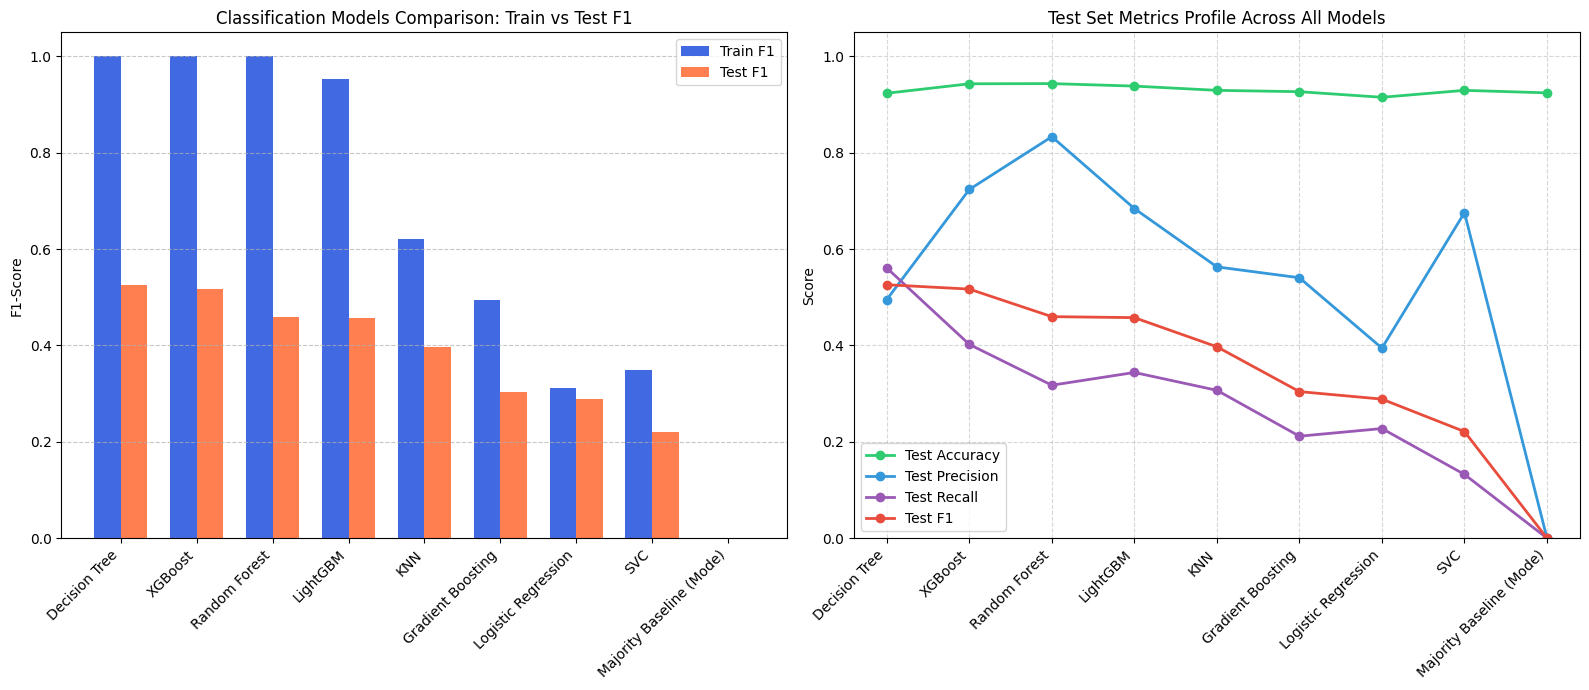

In [ ]:
plt.figure(figsize=(16, 7))
x = np.arange(len(all_results)) # Using all_results which has your classification results
width = 0.35

# --- Subplot 1: Train vs Test F1-Score (To spot overfitting easily) ---
ax1 = plt.subplot(1, 2, 1)
ax1.bar(x - width/2, all_results['Train F1'], width, label='Train F1', color='royalblue')
ax1.bar(x + width/2, all_results['Test F1'], width, label='Test F1', color='coral')

ax1.set_ylabel('F1-Score')
ax1.set_title('Classification Models Comparison: Train vs Test F1')
ax1.set_xticks(x)
ax1.set_xticklabels(all_results['Model Name'], rotation=45, ha='right')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Subplot 2: Comprehensive Test Metrics Comparison ---
# This lets you compare Accuracy, Precision, Recall, and F1 on the Test set side-by-side
ax2 = plt.subplot(1, 2, 2)
test_metrics = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

# Plotting only the Test performance across metrics for clean comparison
for i, metric in enumerate(test_metrics):
    ax2.plot(all_results['Model Name'], all_results[metric], marker='o', linewidth=2, label=metric, color=colors[i])

ax2.set_ylabel('Score')
ax2.set_title('Test Set Metrics Profile Across All Models')
ax2.set_xticks(range(len(all_results)))
ax2.set_xticklabels(all_results['Model Name'], rotation=45, ha='right')
ax2.set_ylim(0, 1.05) # Classification metrics are bounded between 0 and 1
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# Save the updated classification chart
plt.savefig(
    os.path.join(OUTPUT_DIR, "initial_classification_models_comparison.png"),
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [ ]:
# Get the top 5 models based on Test RMSE from all_results
top_6_models_names = all_results['Model Name'].head(6).tolist()

print('TOP 6 Models Based on F1 :-')
for model in top_5_models_names:
    print(f"\n  - {model}")
    print(f"    Train F1: {all_results[all_results['Model Name']==model]['Train F1'].iloc[0]:.4f}")
    print(f"    Test F1: {all_results[all_results['Model Name']==model]['Test F1'].iloc[0]:.4f}")

TOP 6 Models Based on F1 :-

  - Decision Tree
    Train F1: 1.0000
    Test F1: 0.5261

  - XGBoost
    Train F1: 1.0000
    Test F1: 0.5170

  - Random Forest
    Train F1: 1.0000
    Test F1: 0.4598

  - LightGBM
    Train F1: 0.9538
    Test F1: 0.4577

  - KNN
    Train F1: 0.6205
    Test F1: 0.3973

  - Gradient Boosting
    Train F1: 0.4948
    Test F1: 0.3042


In [ ]:
tuned_models = {}
best_params = {}

# Initialize models and their parameter grids
tuning_models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'LightGBM': LGBMClassifier(random_state=42, n_jobs=-1),
    'KNN': KNeighborsClassifier(),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

param_grids = {
    'Decision Tree': {
        'criterion': ['gini', 'entropy'],
        'max_depth': [None, 5, 10, 15, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': [None, 'sqrt', 'log2']
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7, 9],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'gamma': [0, 0.1, 0.2]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2'],
        'bootstrap': [True, False]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'num_leaves': [15, 31, 63, 127],
        'max_depth': [-1, 5, 10, 15],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan', 'minkowski'],
        'p': [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 4, 5, 6],
        'subsample': [0.8, 0.9, 1.0],
        'min_samples_split': [2, 5]
    }
}

In [ ]:
print('Start Hyperparameter Tuning for Top 5 Models...')
for model_name in top_6_models_names:
    if model_name in tuning_models and model_name in param_grids:
        print(f'    Tuning {model_name}...')
        model = tuning_models[model_name]
        param_grid = param_grids[model_name]

        grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid,
                                   scoring='f1', cv=3, n_jobs=-1, verbose=1, random_state=42)

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        tuned_models[model_name] = best_model
        best_params[model_name] = grid_search.best_params_

        train_pred = best_model.predict(X_train)
        test_pred = best_model.predict(X_test)

        if hasattr(model, "predict_proba"):
            train_prob = best_model.predict_proba(X_train)[:, 1]
            test_prob = best_model.predict_proba(X_test)[:, 1]
        else:
            train_prob = None
            test_prob = None

        acc_tr, f1_tr, prec_tr, rec_tr, roc_tr = calc_classification_metrics(y_train, train_pred, train_prob)
        acc_te, f1_te, prec_te, rec_te, roc_te = calc_classification_metrics(y_test, test_pred, test_prob)

        results.append({
            'Model Name': f'{model_name} (tunned)',
            'Model': best_model,
            'Train Accuracy': acc_tr,
            'Test Accuracy': acc_te,
            'Train F1': f1_tr,
            'Test F1': f1_te,
            'Train Precision': prec_tr,
            'Test Precision': prec_te,
            'Train Recall': rec_tr,
            'Test Recall': rec_te,
            'Train ROC-AUC': roc_tr,
            'Test ROC-AUC': roc_te
        })

        print(f'    [DONE] ({model_name} Tuned finished), Best Parameters: {grid_search.best_params_}, Test F1: {f1_te:.4f}\n')
    else:
        print(f'    [SKIP] tuning for {model_name}.\n')

print(f'Hyperparameter Tuning Done. ({len(tuned_models)} models tuned)')

Start Hyperparameter Tuning for Top 5 Models...
    Tuning Decision Tree...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    [DONE] (Decision Tree Tuned finished), Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy'}, Test F1: 0.4313

    Tuning XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    [DONE] (XGBoost Tuned finished), Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.8}, Test F1: 0.4894

    Tuning Random Forest...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
    [DONE] (Random Forest Tuned finished), Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}, Test F1: 0.5132

    Tuning LightGBM...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Warning] 

In [ ]:
tuning_res = []

for name,model in tuned_models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        train_prob = model.predict_proba(X_train)[:, 1]
        test_prob = model.predict_proba(X_test)[:, 1]
    else:
        train_prob = None
        test_prob = None

    acc_tr, f1_tr, prec_tr, rec_tr, roc_tr = calc_classification_metrics(y_train, y_train_pred, train_prob)
    acc_te, f1_te, prec_te, rec_te, roc_te = calc_classification_metrics(y_test, y_test_pred, test_prob)

    tuning_res.append({
        'Model Name': name,
        'Train Accuracy': acc_tr,
        'Test Accuracy': acc_te,
        'Train F1': f1_tr,
        'Test F1': f1_te,
        'Train Precision': prec_tr,
        'Test Precision': prec_te,
        'Train Recall': rec_tr,
        'Test Recall': rec_te,
        'Train ROC-AUC': roc_tr,
        'Test ROC-AUC': roc_te
    })
    print(f"- ({name}) | TRAIN Acc: {acc_tr:.4f}, F1: {f1_tr:.4f} | Test Acc: {acc_te:.4f}, F1: {f1_te:.4f}")

- (Decision Tree) | TRAIN Acc: 0.9899, F1: 0.9359 | Test Acc: 0.9156, F1: 0.4313
- (XGBoost) | TRAIN Acc: 0.9984, F1: 0.9901 | Test Acc: 0.9424, F1: 0.4894
- (Random Forest) | TRAIN Acc: 0.9991, F1: 0.9942 | Test Acc: 0.9484, F1: 0.5132
- (LightGBM) | TRAIN Acc: 1.0000, F1: 1.0000 | Test Acc: 0.9532, F1: 0.6061
- (KNN) | TRAIN Acc: 0.9637, F1: 0.7514 | Test Acc: 0.9268, F1: 0.4438
- (Gradient Boosting) | TRAIN Acc: 1.0000, F1: 1.0000 | Test Acc: 0.9480, F1: 0.5548


In [ ]:
res_df = pd.DataFrame(tuning_res).sort_values(by='Test F1', ascending=False).reset_index(drop=True)
res_df.style.background_gradient(cmap='viridis', subset=res_df.keys()[1:])

# res_df = pd.DataFrame(tuning_res).drop('Model', axis=1).sort_values(by='Test F1', ascending=False).reset_index(drop=True)
# res_df.style.background_gradient(cmap='viridis', subset=res_df.keys()[1:])

,Model Name,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall,Train ROC-AUC,Test ROC-AUC
0,LightGBM,1.000000,0.953181,1.000000,0.606061,1.000000,0.833333,1.000000,0.476190,1.000000,0.914590
1,Gradient Boosting,1.000000,0.947979,1.000000,0.554795,1.000000,0.786408,1.000000,0.428571,1.000000,0.910552
2,Random Forest,0.999066,0.948379,0.994239,0.513208,1.000000,0.894737,0.988543,0.359788,1.000000,0.920323
3,XGBoost,0.998399,0.942377,0.990083,0.489362,1.000000,0.741935,0.980360,0.365079,1.000000,0.896995
4,KNN,0.963704,0.926771,0.751371,0.443769,0.850932,0.521429,0.672668,0.386243,0.981810,0.794301
5,Decision Tree,0.989859,0.915566,0.935919,0.431267,0.965217,0.439560,0.908347,0.423280,0.999224,0.739515


In [ ]:
all_results = pd.DataFrame(results).drop('Model', axis=1).sort_values(by='Test F1', ascending=False).reset_index(drop=True)
all_results.style.background_gradient(cmap='viridis', subset=all_results.keys()[1:])

,Model Name,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall,Train ROC-AUC,Test ROC-AUC
0,Gradient Boosting (tunned),1.000000,0.953181,1.000000,0.606061,1.000000,0.833333,1.000000,0.476190,1.000000,0.914590
1,LightGBM (tunned),1.000000,0.953181,1.000000,0.606061,1.000000,0.833333,1.000000,0.476190,1.000000,0.914590
2,Gradient Boosting (tunned),1.000000,0.947979,1.000000,0.554795,1.000000,0.786408,1.000000,0.428571,1.000000,0.910552
3,Gradient Boosting (tunned),1.000000,0.947979,1.000000,0.554795,1.000000,0.786408,1.000000,0.428571,1.000000,0.910552
4,Decision Tree,1.000000,0.923569,1.000000,0.526055,1.000000,0.495327,1.000000,0.560847,1.000000,0.757047
5,XGBoost,1.000000,0.943177,1.000000,0.517007,1.000000,0.723810,1.000000,0.402116,1.000000,0.897169
6,Random Forest (tunned),0.999066,0.948379,0.994239,0.513208,1.000000,0.894737,0.988543,0.359788,1.000000,0.920323
7,Gradient Boosting (tunned),0.999066,0.948379,0.994239,0.513208,1.000000,0.894737,0.988543,0.359788,1.000000,0.920323
8,Gradient Boosting (tunned),0.998399,0.942377,0.990083,0.489362,1.000000,0.741935,0.980360,0.365079,1.000000,0.896995
9,XGBoost (tunned),0.998399,0.942377,0.990083,0.489362,1.000000,0.741935,0.980360,0.365079,1.000000,0.896995


In [ ]:
print('Start Hyperparameter Tuning for Top 5 Models...')
for model_name in top_6_models_names:
    if model_name in tuning_models and model_name in param_grids:
        print(f'    Tuning {model_name}...')
        model = tuning_models[model_name]
        param_grid = param_grids[model_name]

        grid_search = RandomizedSearchCV(estimator=model, param_distributions=param_grid,
                                   scoring='f1', cv=5, n_jobs=-1, verbose=1, random_state=42)

        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        tuned_models[model_name] = best_model
        best_params[model_name] = grid_search.best_params_

        train_pred = best_model.predict(X_train)
        test_pred = best_model.predict(X_test)

        if hasattr(model, "predict_proba"):
            train_prob = best_model.predict_proba(X_train)[:, 1]
            test_prob = best_model.predict_proba(X_test)[:, 1]
        else:
            train_prob = None
            test_prob = None

        acc_tr, f1_tr, prec_tr, rec_tr, roc_tr = calc_classification_metrics(y_train, train_pred, train_prob)
        acc_te, f1_te, prec_te, rec_te, roc_te = calc_classification_metrics(y_test, test_pred, test_prob)

        results.append({
            'Model Name': f'{model_name} (tunned v2)',
            'Model': best_model,
            'Train Accuracy': acc_tr,
            'Test Accuracy': acc_te,
            'Train F1': f1_tr,
            'Test F1': f1_te,
            'Train Precision': prec_tr,
            'Test Precision': prec_te,
            'Train Recall': rec_tr,
            'Test Recall': rec_te,
            'Train ROC-AUC': roc_tr,
            'Test ROC-AUC': roc_te
        })

        print(f'    [DONE] ({model_name} Tuned finished), Best Parameters: {grid_search.best_params_}, Test F1: {f1_te:.4f}\n')
    else:
        print(f'    [SKIP] tuning for {model_name}.\n')

print(f'Hyperparameter Tuning Done. ({len(tuned_models)} models tuned)')

Start Hyperparameter Tuning for Top 5 Models...
    Tuning Decision Tree...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
    [DONE] (Decision Tree Tuned finished), Best Parameters: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 20, 'criterion': 'entropy'}, Test F1: 0.4313

    Tuning XGBoost...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
    [DONE] (XGBoost Tuned finished), Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.2, 'gamma': 0.2, 'colsample_bytree': 0.8}, Test F1: 0.4894

    Tuning Random Forest...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
    [DONE] (Random Forest Tuned finished), Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}, Test F1: 0.5113

    Tuning LightGBM...
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Warning

In [ ]:
all_results = pd.DataFrame(results).drop('Model', axis=1).sort_values(by='Test F1', ascending=False).reset_index(drop=True)
all_results.style.background_gradient(cmap='viridis', subset=all_results.keys()[1:])

,Model Name,Train Accuracy,Test Accuracy,Train F1,Test F1,Train Precision,Test Precision,Train Recall,Test Recall,Train ROC-AUC,Test ROC-AUC
0,LightGBM (tunned v2),1.000000,0.954382,1.000000,0.620000,1.000000,0.837838,1.000000,0.492063,1.000000,0.913839
1,LightGBM (tunned),1.000000,0.953181,1.000000,0.606061,1.000000,0.833333,1.000000,0.476190,1.000000,0.914590
2,Gradient Boosting (tunned),1.000000,0.953181,1.000000,0.606061,1.000000,0.833333,1.000000,0.476190,1.000000,0.914590
3,Gradient Boosting (tunned),1.000000,0.947979,1.000000,0.554795,1.000000,0.786408,1.000000,0.428571,1.000000,0.910552
4,Gradient Boosting (tunned v2),1.000000,0.947979,1.000000,0.554795,1.000000,0.786408,1.000000,0.428571,1.000000,0.910552
5,Gradient Boosting (tunned),1.000000,0.947979,1.000000,0.554795,1.000000,0.786408,1.000000,0.428571,1.000000,0.910552
6,Decision Tree,1.000000,0.923569,1.000000,0.526055,1.000000,0.495327,1.000000,0.560847,1.000000,0.757047
7,XGBoost,1.000000,0.943177,1.000000,0.517007,1.000000,0.723810,1.000000,0.402116,1.000000,0.897169
8,Random Forest (tunned),0.999066,0.948379,0.994239,0.513208,1.000000,0.894737,0.988543,0.359788,1.000000,0.920323
9,Gradient Boosting (tunned),0.999066,0.948379,0.994239,0.513208,1.000000,0.894737,0.988543,0.359788,1.000000,0.920323


In [ ]:
all_results = pd.DataFrame(results).sort_values(by='Test F1', ascending=False).reset_index(drop=True)
top_model_raw = all_results.iloc[0]
top_model_name = [name.replace(' ','_') for name in top_model_raw['Model Name']]
top__model = top_model_raw['Model']

print(f"- {model_name}")

try:
    with open(os.path.join(OUTPUT_DIR,f'{model_name}_return_predection.pkt'), 'wb') as f:
        pickle.dump(model, f)
    print(f'        [DONE] Model saved successfully at {f}')
except Exception as e:
    print(f'        [FAILD] to save model {model_name}')
    print(f'        Exeption: {type(e).__name__}')
    print(f'        Message: {e}\n')

- Gradient Boosting
        [DONE] Model saved successfully at <_io.BufferedWriter name='/content/outputs/Gradient Boosting_return_predection.pkt'>


In [ ]:
top_model_raw

,0
Model Name,LightGBM (tunned v2)
Train Accuracy,1.0
Test Accuracy,0.954382
Train F1,1.0
Test F1,0.62
Train Precision,1.0
Test Precision,0.837838
Train Recall,1.0
Test Recall,0.492063
Train ROC-AUC,1.0


In [ ]:
results_df = pd.DataFrame(results)
top_model_raw = results_df.iloc[25]

top_model_name = top_model_raw['Model Name'].split()[0]
top_model = top_model_raw['Model']

In [ ]:
print(top_model_name)
top_model

LightGBM


LGBMClassifier(max_depth=15, n_estimators=300, n_jobs=-1, num_leaves=127,
               random_state=42, subsample=0.8)

EVALUATION REPORT FOR: LGBMClassifier

[INFO] Core Performance Metrics Summary:
   Metric  Train   Test
 Accuracy 1.0000 0.9544
Precision 1.0000 0.8378
   Recall 1.0000 0.4921
 F1-Score 1.0000 0.6200
  ROC-AUC 1.0000 0.9138
------------------------------------------------------------

[INFO] Detailed Test Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      2310
           1       0.84      0.49      0.62       189

    accuracy                           0.95      2499
   macro avg       0.90      0.74      0.80      2499
weighted avg       0.95      0.95      0.95      2499

------------------------------------------------------------


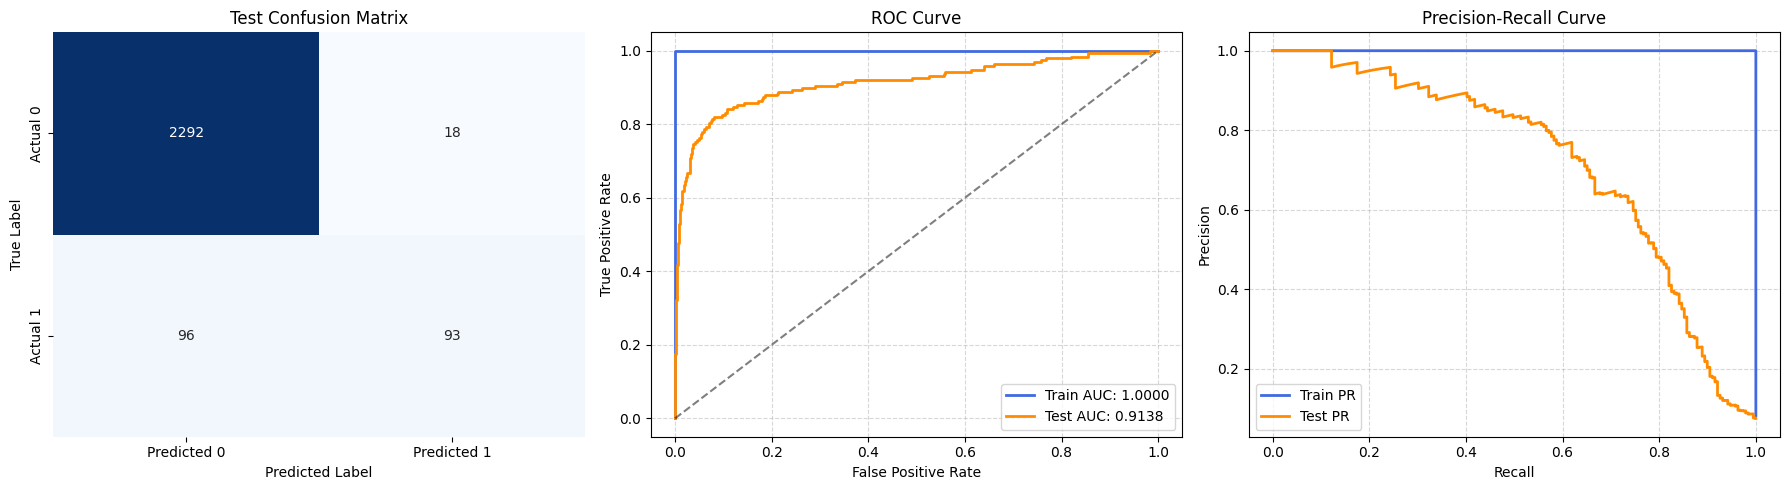

[SUCCESS] Diagnostic visual plots successfully saved to: /content/outputs/LGBMClassifier_evaluation.png



In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*60)
print(f"EVALUATION REPORT FOR: {type(top_model).__name__}")
print("="*60)

# 1. Generate Predictions
y_train_pred = top_model.predict(X_train)
y_test_pred = top_model.predict(X_test)

# Predicted probabilities for the positive class (class 1)
y_train_prob = top_model.predict_proba(X_train)[:, 1]
y_test_prob = top_model.predict_proba(X_test)[:, 1]

# 2. Calculate and Display Core Metrics Table
metrics = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Train': [
        accuracy_score(y_train, y_train_pred),
        precision_score(y_train, y_train_pred, zero_division=0),
        recall_score(y_train, y_train_pred, zero_division=0),
        f1_score(y_train, y_train_pred, zero_division=0),
        roc_auc_score(y_train, y_train_prob)
    ],
    'Test': [
        accuracy_score(y_test, y_test_pred),
        precision_score(y_test, y_test_pred, zero_division=0),
        recall_score(y_test, y_test_pred, zero_division=0),
        f1_score(y_test, y_test_pred, zero_division=0),
        roc_auc_score(y_test, y_test_prob)
    ]
}

metrics_df = pd.DataFrame(metrics)
print("\n[INFO] Core Performance Metrics Summary:")
print(metrics_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("-" * 60)

# 3. Text-Based Classification Report (Precision, Recall per class)
print("\n[INFO] Detailed Test Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))
print("-" * 60)

# 4. Plotting Diagnostic Charts
plt.figure(figsize=(18, 5))

# --- Plot A: Confusion Matrix ---
ax1 = plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
ax1.set_title('Test Confusion Matrix')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')

# --- Plot B: ROC Curve ---
ax2 = plt.subplot(1, 3, 2)
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_prob)
fpr_test, tpr_test, _ = roc_curve(y_test, y_test_prob)

ax2.plot(fpr_train, tpr_train, label=f"Train AUC: {metrics['Train'][4]:.4f}", color='royalblue', lw=2)
ax2.plot(fpr_test, tpr_test, label=f"Test AUC: {metrics['Test'][4]:.4f}", color='darkorange', lw=2)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.5) # Random guess reference line
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve')
ax2.legend(loc='lower right')
ax2.grid(True, linestyle='--', alpha=0.5)

# --- Plot C: Precision-Recall Curve ---
ax3 = plt.subplot(1, 3, 3)
prec_train, rec_train, _ = precision_recall_curve(y_train, y_train_prob)
prec_test, rec_test, _ = precision_recall_curve(y_test, y_test_prob)

ax3.plot(rec_train, prec_train, label='Train PR', color='royalblue', lw=2)
ax3.plot(rec_test, prec_test, label='Test PR', color='darkorange', lw=2)
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve')
ax3.legend(loc='lower left')
ax3.grid(True, linestyle='--', alpha=0.5)

# Save compilation figure
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, f"{type(top_model).__name__}_evaluation.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"[SUCCESS] Diagnostic visual plots successfully saved to: {plot_path}\n")

In [ ]:
try:
    with open(os.path.join(model_path,f'Returned_prediction_model.pkl'), 'wb') as f:
        pickle.dump(top_model, f)
    print(f'        [DONE] Model saved successfully at {f}')
except Exception as e:
    print(f'        [FAILD] to save model {top_model_name}')
    print(f'        Exeption: {type(e).__name__}')
    print(f'        Message: {e}\n')

        [DONE] Model saved successfully at <_io.BufferedWriter name='/content/models/Returned_prediction_model.pkl'>
